In [1]:
import warnings
warnings.filterwarnings("ignore", message="numpy.dtype size changed")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
import random
import tempfile
import gzip
import pylhe
import math
from scipy.optimize import curve_fit
from mpl_toolkits.mplot3d import Axes3D
from auxPlots import  xSecTest, getInfoSMS
from aux import getLHEevents, getDistributions, getInfo, getInfoSummary
from matplotlib.ticker import FixedLocator

pd.option_context('display.max_columns', -1)

pd.options.mode.chained_assignment = None #Disable copy warnings
# plt.style.use('fivethirtyeight') #Set style
# mpl.rcParams.update({'figure.figsize' : (15,10)})  #Set general plotting options
plt.rcParams['figure.max_open_warning'] = 50
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica"]})

plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'

plt.rcParams.update({"savefig.dpi" : 300}) #Figure resolution


#Define plotting style:
sns.set() #Set style
sns.set_style('ticks',{'font.family':'Times New Roman', 'font.serif':'Times New Roman'})
sns.set_context('paper', font_scale=1.8)
cm = plt.colormaps['RdYlBu']

In [2]:
def selectColor(model, process):
    if model == 'VLF EFT':
        return sns.color_palette('Paired')[0]
    elif model == '1-loop VLF':
        return sns.color_palette('Paired')[1]
    elif model == 'Scalar EFT':
        return sns.color_palette('Paired')[2]
    elif model == 'SM':
        return sns.color_palette('Paired')[9]
    else:
        return sns.color_palette('Paired')[3]

In [3]:
def selectColor1(model, process):
    if model == '1-loop VLF':
        if process == r'$q q \to t \bar{t}$':
            return sns.color_palette("RdPu", n_colors=4 + 3)[3]
        else:
            return sns.color_palette("RdPu", n_colors=4 + 3)[4]
    elif model == '1-loop Scalar':
        if process == r'$q q \to t \bar{t}$':
            return sns.color_palette("GnBu", n_colors=4 + 3)[3]
        else:
            return sns.color_palette("GnBu", n_colors=4 + 3)[5]
    else:
        return sns.color_palette('Paired')[3]

# Combining the process to obtain $pp \to t\bar{t}$

In [233]:
files = list(glob.glob('/home/vinicius/EFT_ToyModel/processFolders/Distributions/bias/*/*/bias_article/*500*.npz'))
data = []
for f in files:
    aux = np.load(f, allow_pickle = True)
    data.append(aux)
print(data)    
data = sorted(data, key=lambda d: (d['mass_params'][0], d['mass_params'][1]))

[NpzFile '/home/vinicius/EFT_ToyModel/processFolders/Distributions/bias/UV_BSM/gg2ttbar_gs4_ydm2/bias_article/mPsiT_500_mSDM_475.npz' with keys: mTT, pT1, pT2, deltaPhi, weights..., NpzFile '/home/vinicius/EFT_ToyModel/processFolders/Distributions/bias/UV_BSM/qq2ttbar_gs4_ydm2/bias_article/mPsiT_500_mSDM_475.npz' with keys: mTT, pT1, pT2, deltaPhi, weights..., NpzFile '/home/vinicius/EFT_ToyModel/processFolders/Distributions/bias/SMS_1_loop/gg2ttbar_gs4_ydm2/bias_article/mPsiT_500_mSDM_475.npz' with keys: mTT, pT1, pT2, deltaPhi, weights..., NpzFile '/home/vinicius/EFT_ToyModel/processFolders/Distributions/bias/SMS_1_loop/qq2ttbar_gs4_ydm2/bias_article/mPsiT_500_mSDM_475.npz' with keys: mTT, pT1, pT2, deltaPhi, weights...]


In [234]:
#Reading files with bias
sm_files = list(glob.glob('/home/vinicius/EFT_ToyModel/processFolders/Distributions/bias/sm/pp2ttbar_gs4/*.npz'))
print(sm_files)
sm_qq_files = list(glob.glob('/home/vinicius/EFT_ToyModel/processFolders/Distributions/bias/sm/qq2ttbar_gs4/*.npz'))
data_sm_exp = []
data_qq_sm_exp = []
#Loading the distributions
for f in  sm_files:
    aux = np.load(f, allow_pickle = True)
    data_sm_exp.append(aux)
        
for f in  sm_qq_files:
    aux = np.load(f, allow_pickle = True)
    data_qq_sm_exp.append(aux)

data_sm_exp = sorted(data_sm_exp, key=lambda d: d['mass_params'][0])
print(data_sm_exp[0]['process'])

['/home/vinicius/EFT_ToyModel/processFolders/Distributions/bias/sm/pp2ttbar_gs4/mPsiT_0_mSDM_0_1.npz', '/home/vinicius/EFT_ToyModel/processFolders/Distributions/bias/sm/pp2ttbar_gs4/mPsiT_0_mSDM_0.npz']
$p p \to t \bar{t}$


In [235]:
data_NLO = []
for d in data:
    if '1-loop VLF' in d['model'] or '1-loop Scalar' in d['model']:
        data_NLO.append(d)

data_NLO = sorted(data_NLO, key=lambda d: (d['mass_params'][0], d['mass_params'][1]))

In [236]:
for d in data_NLO:
    print(d['nevents'])

822950
866698
1169531
870242


In [271]:
#Reading files with bias
fake_data_files = list(glob.glob('/home/vinicius/EFT_ToyModel/processFolders/Distributions/bias/VLF/pp2ttbar/bias_article*/*500*.npz'))
print(fake_data_files)
fake_data = []


for f in fake_data_files:
    aux = np.load(f, allow_pickle = True)
    fake_data.append(aux)

#fake_data = sorted(fake_data, key=lambda d: (d['mPsiT'], d['mSDM']))
#print(fake_data['yDM'])
soma = 0.0
for i in fake_data:
    soma+=i['nevents']
print(soma)

['/home/vinicius/EFT_ToyModel/processFolders/Distributions/bias/VLF/pp2ttbar/bias_article_500_475/mPsiT_500_mSDM_475.npz']
1548154.0


In [232]:
def load_npz_data(file_pattern):
    """Loads and concatenates data from all .npz files matching a pattern."""
    files = glob.glob(file_pattern)
    mtt_list, weights_list = [], []
    for f in files:
        data = np.load(f)
        mtt_list.append(data['mTT'])
        weights_list.append(data['weights'])
    if mtt_list:
        return np.concatenate(mtt_list), np.concatenate(weights_list)
    return np.array([]), np.array([])

# ====================================================================
# Load the raw Pseudo-Data files ONCE at the beginning of the script
# ====================================================================
path_fake_sm = "/home/vinicius/EFT_ToyModel/processFolders/Distributions/bias/sm/pp2ttbar_gs4/pseudo_data/*.npz"
path_fake_qq = "/home/vinicius/EFT_ToyModel/processFolders/Distributions/bias/UV_BSM/qq2ttbar_gs4_ydm2/pseudo_data/*.npz"
path_fake_gg = "/home/vinicius/EFT_ToyModel/processFolders/Distributions/bias/UV_BSM/gg2ttbar_gs4_ydm2/pseudo_data/*.npz"

mtt_fake_sm, w_fake_sm = load_npz_data(path_fake_sm)
mtt_fake_qq, w_fake_qq = load_npz_data(path_fake_qq)
mtt_fake_gg, w_fake_gg = load_npz_data(path_fake_gg)

# Define how much you want to rescale the interference term for the fake data
# (e.g., if generated with yDM=2 but you want it to represent yDM=6, use (6/2)**2 = 9.0)
fake_scale_factor = (6.0 )**2

In [44]:
def get_color_by_mass(model, mass):
    mPsiT, mSDM = mass
    
    # --- COLORS FOR VECTOR-LIKE FERMION (VLF) ---
    # Using a progression from bright blue -> dark blue -> purple
    if '1-loop VLF' in model:
        if mPsiT == 500.0 and mSDM == 375.0:
            return 'deepskyblue'   # Bright, distinct blue
        elif mPsiT == 500.0 and mSDM == 475.0:
            return 'dodgerblue'         # Standard pure blue
        elif mPsiT == 600.0 and mSDM == 475.0:
            return 'blue'         # Very dark blue
        elif mPsiT == 1500.0 and mSDM == 1425.0:
            return 'navy'   # Purple-ish blue to separate high mass
        else:
            return 'cornflowerblue' # Fallback

    # --- COLORS FOR SCALAR ---
    # Using a progression from bright green -> dark green -> teal
    elif '1-loop Scalar' in model:
        if mPsiT == 500.0 and mSDM == 375.0:
            return 'chartreuse'    # Bright, distinct green
        elif mPsiT == 500.0 and mSDM == 475.0:
            return 'limegreen'  # Standard deep green
        elif mPsiT == 600.0 and mSDM == 475.0:
            return 'forestgreen'    # Very dark green
        elif mPsiT == 1500.0 and mSDM == 1425.0:
            return 'darkgreen'         # Blue-green to separate high mass
        else:
            return 'mediumseagreen' # Fallback
    elif 'Z prime' in model:
        return sns.color_palette('Paired')[5]

    # --- DEFAULT ---
    else:
        return 'black'

In [267]:

files = list(glob.glob('/home/vinicius/EFT_ToyModel/processFolders/Distributions/bias/z_prime/pp2ttbar_dmv4/bias_*1000_10/*.npz'))
print(files)
#files = list(glob.glob('/home/vinicius/EFT_ToyModel/test/Distributions/*/*/*.npz'))
data_Z = []
#data_sm = []
#Loading the distributions
for f in files:
    aux = np.load(f, allow_pickle = True)
    data_Z.append(aux)

data_Z = sorted(data_Z, key=lambda d: d['mZp'])
print(data_Z[0]['xsec (pb)'])

['/home/vinicius/EFT_ToyModel/processFolders/Distributions/bias/z_prime/pp2ttbar_dmv4/bias_article_1000_10/mZp_1000.npz']
0.035165174



--- KS Test Results (Max CDF Difference D) for mPsiT = 500.0 GeV ---
vs  VLF         -> D = 1.0875  (Max gap at 450 GeV)
vs  Scalar      -> D = 0.7573  (Max gap at 450 GeV)
vs Z'           -> D = 1.4495  (Max gap at 450 GeV)
-----------------------------------------------------------------

\n--- Chi-Squared Test Results for mPsiT = 500.0 GeV ---
vs  VLF         -> Chi2 = 5129563.3 | p-value = 0.00e+00 | Z = 7.94 sigma
vs  Scalar      -> Chi2 = 4134928.8 | p-value = 0.00e+00 | Z = 7.94 sigma
vs Z'           -> Chi2 = 5252149.1 | p-value = 0.00e+00 | Z = 7.94 sigma
-----------------------------------------------------------------



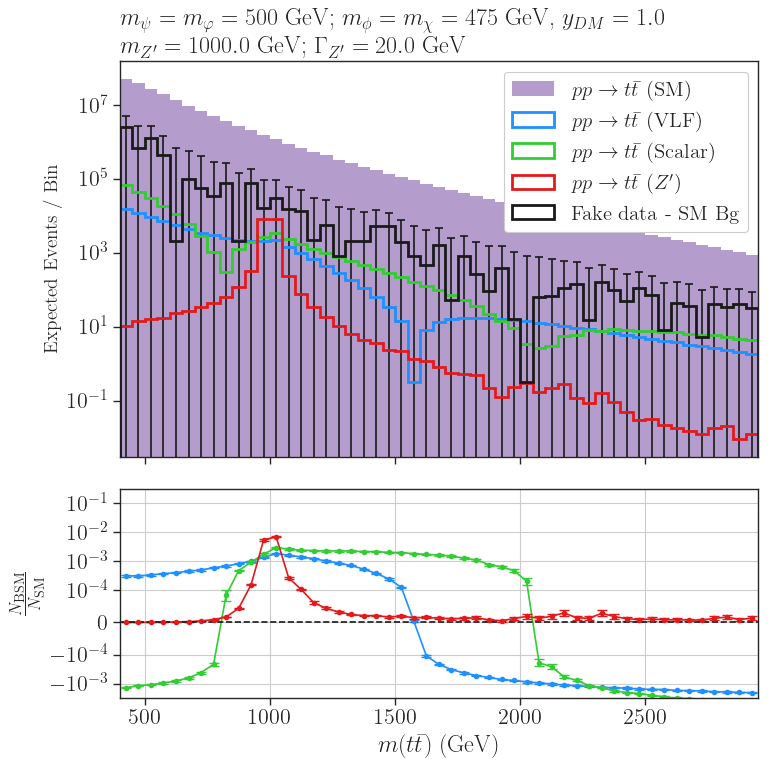

In [272]:

################
# SM err (%)   #
################

lum = 500 # fb^-1

# -------------------------------------------------------------
# LUMINOSITY SCALING FACTOR
# Assuming your MC weights are in picobarns (pb), 1 pb = 1000 fb.
# If your weights are already in fb, change this to: lum_scale = lum
# -------------------------------------------------------------
lum_scale = lum * 1000.0 

sm_err = 0.05

# Loop over the masses configurations. Each mass configuration has 4 items (2 models x 2 processes: qq, gg)
for i in range(0, len(data_NLO), 4):
    selected = data_NLO[i : i+4]

    # BSM masses and couplings
    mPsiT, mSDM = selected[0]['mass_params']
    yDM = selected[0]['ydm']

    # --- Setup and Binning ---
    fig, axarr = plt.subplots(2, sharex=True, gridspec_kw={'height_ratios': [1.9, 1]}, figsize=(8, 8))
    plt.subplots_adjust(left=0.12, bottom=0.12, right=0.97, top=None, wspace=None, hspace=0.1)

    if mPsiT < 600:
        bins = np.arange(400., 3000., 50.)
    elif mPsiT < 1000:
        bins = np.arange(500., 4000., 75.)
    else:
        bins = np.arange(400., 5500., 100.)

    x = (bins[:-1] + bins[1:]) / 2.0
    bin_widths = np.diff(bins)

    ##############
    # Main Plot  #
    ##############

    pmodels = []
    labels_sm = []
    bsm_hists, bsm_errs, bsm_labels, bsm_colors = [], [], [], []

    # Plotting the SM
    h_sm_total = np.zeros(len(bins)-1)
    hErr_sm_total_sq = np.zeros(len(bins)-1)

    for n, d in enumerate(data_sm_exp):
        h, _ = np.histogram(d['mTT'], bins=bins, weights=d['weights'])
        hErr_sq, _ = np.histogram(d['mTT'], bins=bins, weights=np.array(d['weights'])**2)
        
        # Multiply heights by lum_scale, and variance by lum_scale^2
        h_sm_total += h * lum_scale
        hErr_sm_total_sq += hErr_sq * (lum_scale**2)

    process = r'$p p \to t \bar{t}$'
    model = 'SM'
    pmodels.append(r'%s (%s)' % (process, model))
    label_sm = pmodels[-1]
    labels_sm.append(label_sm)

    integral_sm = np.sum(h_sm_total/(n+1))
    h_sm = h_sm_total/(n+1)
    hErr_sm = np.sqrt(hErr_sm_total_sq/((n+1)**2) + (sm_err*h_sm)**2)

    axarr[0].hist(
        bins[:-1], weights=np.abs(h_sm), label=label_sm, bins=bins, 
        color=sns.color_palette('Paired')[9], alpha=0.5, histtype='step',
        linewidth=0, fill=True, zorder=0
    )

    # Plotting the NLO BSM Data (Summing qq + gg for each model)
    #y_DM = {'1-loop VLF': 6.0, '1-loop Scalar': 1.268000e+01}
    y_DM = {'1-loop VLF': 1.0, '1-loop Scalar': 3.06822e+00}
    for j in range(0, len(selected), 2):
        d = selected[j]
        d_next = selected[j+1]

        process = r'$p p \to t \bar{t}$'
        model = d['model']
        model_raw = d['model']
        model_name = str(np.atleast_1d(model_raw)[0])
        display_name = model_name.replace('1-loop ', '')
        pmodels.append(r'%s (%s)' % (process, display_name))
        label = pmodels[-1]

        color = get_color_by_mass(model, (mPsiT, mSDM))

        h1, _ = np.histogram(d['mTT'], bins=bins, weights=d['weights'])
        hErr1_sq, _ = np.histogram(d['mTT'], bins=bins, weights=np.array(d['weights'])**2)

        h2, _ = np.histogram(d_next['mTT'], bins=bins, weights=d_next['weights'])
        hErr2_sq, _ = np.histogram(d_next['mTT'], bins=bins, weights=np.array(d_next['weights'])**2)
        
        scale_weight = y_DM.get(model_name, 1.0)**2 

        # Scale by luminosity!
        h_bsm_total = (h1 + h2) * scale_weight * lum_scale
        hErr_bsm_total_sq = (hErr1_sq + hErr2_sq) * (scale_weight**2)* (lum_scale**2)

        integral_bsm = np.sum(h_bsm_total)
        h_bsm = h_bsm_total
        hErr_bsm = np.sqrt(hErr_bsm_total_sq)

        bsm_hists.append(h_bsm)
        bsm_errs.append(hErr_bsm)
        bsm_labels.append(label)
        bsm_colors.append(color)

        axarr[0].hist(
            bins[:-1], weights=np.abs(h_bsm), label=label, bins=bins,
            color=color, alpha=1.0, histtype='step', 
            linewidth=2, fill=False, zorder=3
        )

    h_z_total = np.zeros(len(bins)-1)
    hErr_z_total_sq = np.zeros(len(bins)-1)
    model_z = ""

    for d in data_Z:
        h, _ = np.histogram(d['mTT'], bins=bins, weights=d['weights'])
        hErr_sq, _ = np.histogram(d['mTT'], bins=bins, weights=np.array(d['weights'])**2)
        
        # Scale Z' by luminosity
        h_z_total += h * lum_scale
        hErr_z_total_sq += hErr_sq * (lum_scale**2)
        model_z = d['model']

    if len(data_Z) > 0:
        process = r'$p p \to t \bar{t}$'
        pmodels.append(r'%s (%s)' % (process, r'$Z^\prime$'))
        label_z = pmodels[-1]

        color_z = get_color_by_mass(model_z, (mPsiT, mSDM))

        integral_z = np.sum(h_z_total)
        h_z = h_z_total
        hErr_z = np.sqrt(hErr_z_total_sq)

        bsm_hists.append(h_z)
        bsm_errs.append(hErr_z)
        bsm_labels.append(label_z)
        bsm_colors.append(color_z)

        axarr[0].hist(
            bins[:-1], weights=np.abs(h_z), label=label_z, bins=bins,
            color=color_z, alpha=1.0, histtype='step', 
            linewidth=2, fill=False, zorder=3
        )

    ############
    # SUBPLOT  #
    ############
    with np.errstate(divide='ignore', invalid='ignore'):
        raw_ratio = np.nan_to_num(np.array(bsm_hists) / h_sm)
        ratio = raw_ratio

        err_bsm_rel = np.nan_to_num(np.array(bsm_errs) / np.array(bsm_hists))
        err_sm_rel = np.nan_to_num(hErr_sm / h_sm)

        ratio_err = np.abs(raw_ratio) * np.sqrt(err_bsm_rel**2 + err_sm_rel**2)

    for k, r in enumerate(ratio):
        axarr[1].errorbar(x, r, yerr=ratio_err[k], color=bsm_colors[k], fmt='o', ms=3, capsize=3.5, label=bsm_labels[k])
        axarr[1].plot(x, r, color=bsm_colors[k])

    ##################################
    # Adding fake data to the hists  #
    ##################################
    h_fake = np.zeros(len(bins)-1)
    
    for n, d in enumerate(fake_data):
        h, _ = np.histogram(d['mTT'], bins=bins, weights=d['weights'])
        h_fake += h * lum_scale
        
    # The total expected observation of the fake data
    N_obs = h_fake / (n + 1)
    
    # -------------------------------------------------------------
    # REALISTIC FAKE DATA ERROR BARS:
    # Since this is "data", the statistical uncertainty is just sqrt(N).
    # We add this Poisson variance to the Expected SM variance!
    # -------------------------------------------------------------
    stat_variance_obs = np.abs(N_obs) # sqrt(N)^2 = N
    
    bsm_hists.append(N_obs - h_sm)
    bsm_errs.append(np.sqrt(stat_variance_obs + hErr_sm**2))
    
    bsm_labels.append('Fake Data - SM Bg')
    bsm_colors.append('k')
    
    axarr[0].hist(
        bins[:-1], weights=np.abs(bsm_hists[-1]), label='Fake data - SM Bg', bins=bins,
        color='k', alpha=1.0, histtype='step', 
        linewidth=2, fill=False, zorder=3
    )
    
    axarr[0].errorbar(
        x, np.abs(bsm_hists[-1]), yerr=bsm_errs[-1], color='k', 
        fmt='none', capsize=3, capthick=1.2, barsabove=True
    )

     ######################################################
    #  KS Test (Testing Fake Data against all Models)    #
    ######################################################
    
    # 1. Define the Observation (The last item in bsm_hists is the Fake Data)
    fake_obs = bsm_hists[-1] 
    
    # 2. Define the Hypotheses to test against
    # Make sure the indices match your loop! 
    # [0] is VLF, [1] is Scalar, [2] is Z' (if available)
    hypotheses = [
        (" VLF", bsm_hists[0]),
        (" Scalar", bsm_hists[1])
    ]
    if len(data_Z) > 0:
        hypotheses.append(("Z'", bsm_hists[2]))
    
    # 3. Ensure we only use valid bins (where SM is greater than 0)
    valid_bins = h_sm > 0
    
    # 4. Calculate normalized CDF for the Fake Data Observation
    fake_yield = fake_obs[valid_bins]
    cdf_fake = np.cumsum(fake_yield)
    cdf_fake_norm = cdf_fake / cdf_fake[-1]
    
    print(f"\n--- KS Test Results (Max CDF Difference D) for mPsiT = {mPsiT} GeV ---")
    
    # 5. Loop through each hypothesis and compute the D statistic
    ks_annotation_text = "KS Test (D-Statistic):\n"
    
    for name, hyp_hist in hypotheses:
        hyp_yield = hyp_hist[valid_bins]
        cdf_hyp = np.cumsum(hyp_yield)
        
        # Normalize hypothesis CDF
        cdf_hyp_norm = cdf_hyp / cdf_hyp[-1]
        
        # Calculate maximum absolute distance
        cdf_differences = np.abs(cdf_hyp_norm - cdf_fake_norm)
        D_statistic = np.max(cdf_differences)
        max_bin_index = np.argmax(cdf_differences)
        mass_at_max = bins[:-1][valid_bins][max_bin_index]
        
        # Print to console
        print(f"vs {name:12s} -> D = {D_statistic:.4f}  (Max gap at {mass_at_max:.0f} GeV)")
        
        # Format for the plot annotation
        ks_annotation_text += f"vs {name}: {D_statistic:.4f}\n"
        
    print("-" * 65 + "\n")

    import scipy.stats as stats

    ######################################################
    #  Chi-Squared Test (Accounting for ALL Uncertainties)
    ######################################################
    
    # 1. Define the Observation (Fake Data is the last item in bsm_hists)
    # NOTE: Ensure your fake data here is the TOTAL observation (SM + Signal), 
    # not the background-subtracted version.
    fake_obs = bsm_hists[-1] 
    
    # The statistical variance of the observation is just N_obs
    stat_variance_obs = np.abs(fake_obs) 
    
    # 2. Define the Hypotheses to test against
    hypotheses = [
        (" VLF", bsm_hists[0], bsm_errs[0]**2),
        (" Scalar", bsm_hists[1], bsm_errs[1]**2)
    ]
    if len(data_Z) > 0:
        hypotheses.append(("Z'", bsm_hists[2], bsm_errs[2]**2))
    
    # 3. Only use bins with enough events (e.g., Expected SM > 0) to avoid division by zero
    valid_bins = h_sm > 0
    degrees_of_freedom = np.sum(valid_bins) - 1 # n_bins - 1
    
    print(rf"\n--- Chi-Squared Test Results for mPsiT = {mPsiT} GeV ---")
    
    chi2_annotation_text = r"$\chi^2$ / ndf (Significance):\n"
    
    for name, hyp_hist, hyp_variance in hypotheses:
        # Get the valid bins for Data and Hypothesis
        O = fake_obs[valid_bins]
        E = hyp_hist[valid_bins]
        
        # Total Variance = Variance(Data) + Variance(Hypothesis)
        # Hypothesis variance already contains the 5% systematic + MC stats!
        total_variance = stat_variance_obs[valid_bins] + hyp_variance[valid_bins]
        
        # Calculate Chi-Squared
        chi2_val = np.sum((O - E)**2 / total_variance)
        
        # Calculate p-value (probability of seeing this deviation by chance)
        p_value = stats.chi2.sf(chi2_val, degrees_of_freedom)
        
        # Convert p-value to Z-score (Sigmas)
        # If p-value is extremely small (perfect rejection), sf can hit 0.0. 
        # We clip it to avoid infinity.
        p_value_clipped = max(p_value, 1e-15)
        z_score = stats.norm.isf(p_value_clipped)
        
        print(rf"vs {name:12s} -> Chi2 = {chi2_val:.1f} | p-value = {p_value:.2e} | Z = {z_score:.2f} sigma")
        
        # Format for plot annotation
        chi2_annotation_text += rf"{name}: {chi2_val:.1f}/{degrees_of_freedom} ({z_score:.1f}$\sigma$)\n"
        
    print("-" * 65 + "\n")

   
    
    #################
    # Plot configs  #
    #################

    mZp = data_Z[0].get('mZp', 0.0) if len(data_Z) > 0 else 0.0
    wZp = data_Z[0].get('wZp', 0.0) if len(data_Z) > 0 else 0.0

    # Upper plot
    axarr[0].legend(framealpha=1.0, ncol=1, loc='upper right', fontsize=15)
    axarr[0].set_title(
        (r'$m_{\psi} = m_{\varphi} = %1.0f$ GeV; $m_{\phi} = m_\chi = %1.0f$ GeV, $y_{DM} = %1.1f$' + '\n' +
         r'$m_{Z^\prime} = %1.1f$ GeV; $\Gamma_{Z^\prime} = %1.1f$ GeV') %
        (mPsiT, mSDM, yDM, mZp, 20.0),
        loc='left'
    )
    axarr[0].set_yscale('log')
    
    # CHANGED Y-AXIS LABEL TO REFLECT EXPECTED EVENTS
    axarr[0].set_ylabel(r'Expected Events / Bin', fontsize=14)
    axarr[0].set_xlim(bins.min(), bins.max())

    # Bottom plot
    axarr[1].axhline(y=0, color='k', linestyle='--')
    axarr[1].set_ylabel(r'$\frac{N_{\mathrm{BSM}}}{ N_{\mathrm{SM}}}$')
    axarr[1].set_xlabel(r'$m(t\bar{t})$ (GeV)')
    axarr[1].grid(True)
    axarr[1].set_yscale('symlog', linthresh=0.0001)
    axarr[1].set_ylim([-0.003, 0.3])

    minor_tick_locations = np.concatenate((
        np.arange(-100.0, 0.0, 10.0), np.arange(-10.0, 1.0, 1.0), np.arange(0.0, 11.0, 1.0),
        np.arange(10.0, 100.0, 10.0), np.arange(100.0, 1100.0, 100.0), np.arange(1000.0, 4000.0, 1000.0)
    ))
    axarr[1].yaxis.set_minor_locator(FixedLocator(minor_tick_locations))

    plt.tight_layout()
    plt.savefig('Dists_comparison_interference.png')
    plt.show()

In [274]:
mTT_start = 1.5 * mPsiT
tail_mask = bins[:-1] >= mTT_start


tail_sum_NLO = np.sum(bsm_hists[0][tail_mask]) 
tail_sum_S   = np.sum( bsm_hists[1][tail_mask] )
tail_sum_Zp  = np.sum( bsm_hists[2][tail_mask]) 

yDM_S = np.sqrt( tail_sum_NLO/tail_sum_S)
mu_Zp = np.sqrt(tail_sum_NLO/tail_sum_Zp)
# Print the results
print(f"--- Sum for mTT >= {mTT_start} GeV ---")
print(f"VLF NLO:      {tail_sum_NLO:.5e}")
print(f"Scalar NLO:   {tail_sum_S:.5e}")
print(f"Z prime:      {tail_sum_Zp:.5e}")
print(f"yDM_S:      {yDM_S:.5e}")
print(f"mu_Z:      {mu_Zp:.5e}")
print()



--- Sum for mTT >= 750.0 GeV ---
VLF NLO:      1.79056e+04
Scalar NLO:   1.79056e+04
Z prime:      1.74357e+04
yDM_S:      9.99999e-01
mu_Z:      1.01339e+00



1000.0


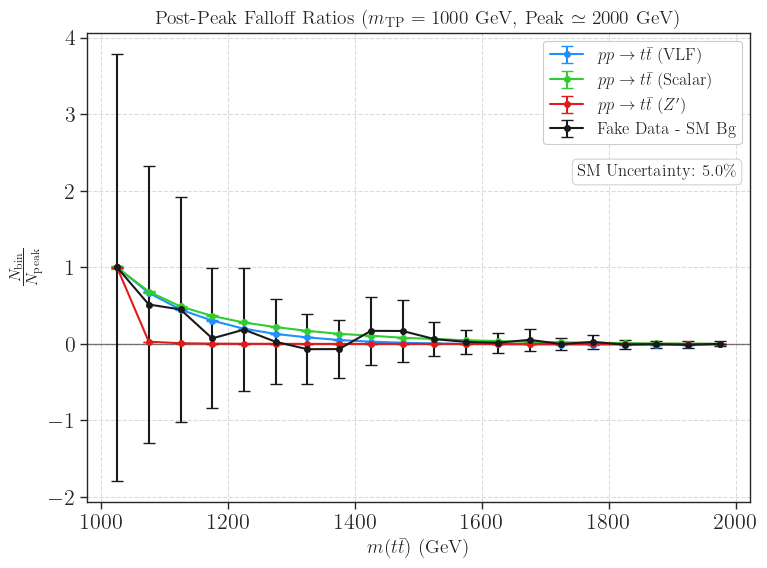

In [278]:
mTP = 500.0 #GeV
n_bp = 20
peak = 2.0 * mTP
b_peak = 0
i = 0

while (peak >= bins[i] and i<=len(bins)):
    b_peak = i
    i+=1
print(bins[b_peak])
ratios = []

ratios_err = []

ratios = []
ratios_err = []

# Computing the ratios
for i, h in enumerate(bsm_hists):
    aux = []
    err = []
    for j in range(b_peak , b_peak + n_bp):
        A = h[j]
        B = h[b_peak]
        errA = bsm_errs[i][j]
        errB = bsm_errs[i][b_peak]
        
        aux.append(A / B)
        
        # Safe propagation: avoids dividing by zero if the tail crosses zero
        safe_err = np.sqrt((errA / B)**2 + (A * errB / (B**2))**2)
        err.append(safe_err)
        
    ratios.append(aux)
    ratios_err.append(err)

# ==========================================
# Plotting the ratios for each model
# ==========================================

# Calculate the bin centers for the x-axis
x_centers = [(bins[j] + bins[j+1]) / 2.0 for j in range(b_peak , b_peak + n_bp)]

fig, ax = plt.subplots(figsize=(8, 6))

# Loop over the calculated ratios to plot them
for k in range(len(ratios)):
    label = bsm_labels[k] if 'bsm_labels' in locals() else f"Model {k+1}"
    color = bsm_colors[k] if 'bsm_colors' in locals() else None
    
    ax.errorbar(x_centers, ratios[k], yerr=ratios_err[k], fmt='o-', 
                capsize=4, label=label, color=color, markersize=4, linewidth=1.5)
ax.text(0.98, 0.72, rf'SM Uncertainty: {sm_err*100:.1f}\%', 
        transform=ax.transAxes,      # Use axis coordinates instead of mass data coordinates
        fontsize=12, 
        verticalalignment='top',     # Anchor the text from its top edge
        horizontalalignment='right', # Anchor the text from its right edge
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='lightgray', alpha=1.0))

# Formatting the plot to match the style of your previous physics plots
ax.set_xlabel(r'$m(t\bar{t})$ (GeV)', fontsize=14)
ax.set_ylabel(r'$\frac{N_{\mathrm{bin}}}{N_{\mathrm{peak}}}$', fontsize=16)
ax.set_title(r'Post-Peak Falloff Ratios ($m_{\mathrm{TP}} = 1000$ GeV, Peak $\simeq 2000$ GeV)', fontsize=14)

# Adding a horizontal line at 0 so you can clearly see the negative interference crossing!
ax.axhline(0, color='black', linestyle='-', linewidth=1, alpha=0.5)

ax.grid(True, linestyle='--', alpha=0.7)
ax.legend(fontsize=12, framealpha=1.0)
#ax.set_yscale('log')
plt.tight_layout()
#plt.savefig('Post_Peak_Falloff.png', dpi=300)
plt.show()

Peak bin starts at: 1000.0


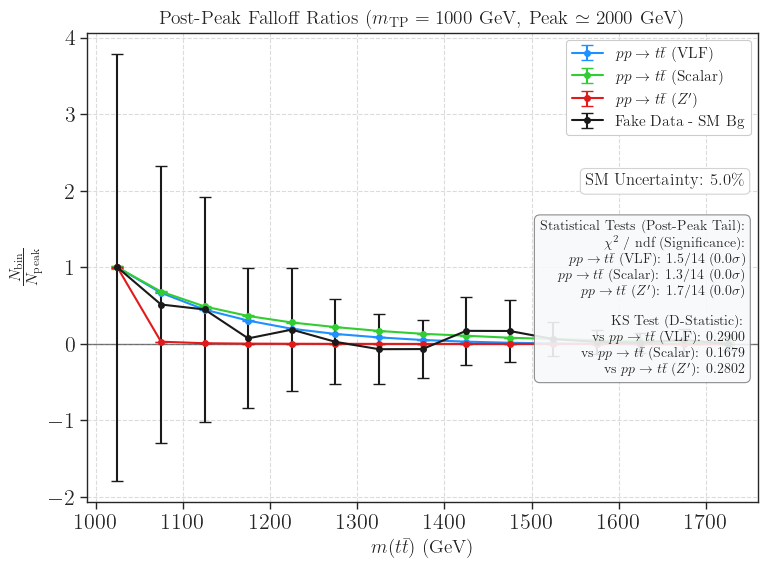

In [277]:

mTP = 500.0 #GeV
n_bp = 15
peak = 2.0 * mTP
b_peak = 0
i = 0

while (peak >= bins[i] and i<=len(bins)):
    b_peak = i
    i+=1
print(f"Peak bin starts at: {bins[b_peak]}")

ratios = []
ratios_err = []

# Computing the ratios
for i, h in enumerate(bsm_hists):
    aux = []
    err = []
    # Loop starts at b_peak, but we will ignore the 0th element in the stats test!
    for j in range(b_peak, b_peak + n_bp):
        A = h[j]
        B = h[b_peak]
        errA = bsm_errs[i][j]
        errB = bsm_errs[i][b_peak]
        
        aux.append(A / B)
        
        # Safe propagation: avoids dividing by zero if the tail crosses zero
        safe_err = np.sqrt((errA / B)**2 + (A * errB / (B**2))**2)
        err.append(safe_err)
        
    ratios.append(aux)
    ratios_err.append(err)

# ==========================================
# Statistical Tests (Fake Data vs Theory)
# ==========================================
# Assuming Fake Data is the LAST element in your lists
fake_ratio = np.array(ratios[-1])
fake_ratio_err = np.array(ratios_err[-1])

# We slice [1:] to skip the b_peak itself 
valid_fake_ratio = fake_ratio[1:]
valid_fake_err = fake_ratio_err[1:]

stats_lines = [
    "Statistical Tests (Post-Peak Tail):",
    r"$\chi^2$ / ndf (Significance):"
]

for k in range(len(ratios) - 1): # Skip the last element (which is Fake Data itself)
    hyp_ratio = np.array(ratios[k])[1:]
    hyp_err = np.array(ratios_err[k])[1:]
    name = bsm_labels[k]
    
    # -----------------------------------------------------------------
    # MATH FIX: To treat the bins as independent for a standard Chi2, 
    # we isolate the variance of just the NUMERATOR (the tail bins) 
    # and ignore the shared denominator error that bloats the variance.
    # -----------------------------------------------------------------
    # Extract the raw numerator errors from the original arrays
    raw_err_fake = np.array(bsm_errs[-1])[b_peak+1 : b_peak+n_bp] / bsm_hists[-1][b_peak]
    raw_err_hyp  = np.array(bsm_errs[k])[b_peak+1 : b_peak+n_bp] / bsm_hists[k][b_peak]
    
    total_variance = raw_err_fake**2 + raw_err_hyp**2
    
    # Calculate Chi2
    valid_mask = total_variance > 0
    ndf = np.sum(valid_mask)
    
    if ndf > 0:
        chi2_val = np.sum((valid_fake_ratio[valid_mask] - hyp_ratio[valid_mask])**2 / total_variance[valid_mask])
        p_value = stats.chi2.sf(chi2_val, ndf)
        
        # PYTHON FIX: Cap the p-value at 0.5 to prevent stats.norm.isf from outputting -inf
        if p_value >= 0.5:
            z_score = 0.0
        else:
            z_score = stats.norm.isf(max(p_value, 1e-15))
    else:
        chi2_val, z_score = 0.0, 0.0
    
    stats_lines.append(f"{name}: {chi2_val:.1f}/{ndf} ({z_score:.1f}" + r"$\sigma$)")

# 2. Kolmogorov-Smirnov (KS) Test 
# (Warning: A CDF of a ratio is not a true statistical probability distribution)
stats_lines.append("")
stats_lines.append("KS Test (D-Statistic):")

cdf_fake = np.cumsum(valid_fake_ratio)
cdf_fake_norm = cdf_fake / cdf_fake[-1] if cdf_fake[-1] != 0 else cdf_fake

for k in range(len(ratios) - 1):
    hyp_ratio = np.array(ratios[k])[1:]
    name = bsm_labels[k]
    
    cdf_hyp = np.cumsum(hyp_ratio)
    cdf_hyp_norm = cdf_hyp / cdf_hyp[-1] if cdf_hyp[-1] != 0 else cdf_hyp
    
    D_stat = np.max(np.abs(cdf_fake_norm - cdf_hyp_norm))
    stats_lines.append(f"vs {name}: {D_stat:.4f}")

# Join the list into a single safe string
stats_text = "\n".join(stats_lines)


# ==========================================
# Plotting the ratios for each model
# ==========================================

# Calculate the bin centers for the x-axis
x_centers = [(bins[j] + bins[j+1]) / 2.0 for j in range(b_peak, b_peak + n_bp)]

fig, ax = plt.subplots(figsize=(8, 6))

# Loop over the calculated ratios to plot them
for k in range(len(ratios)):
    label = bsm_labels[k] if 'bsm_labels' in locals() else f"Model {k+1}"
    color = bsm_colors[k] if 'bsm_colors' in locals() else None
    
    ax.errorbar(x_centers, ratios[k], yerr=ratios_err[k], fmt='o-', 
                capsize=4, label=label, color=color, markersize=4, linewidth=1.5)


# Formatting the plot to match the style of your previous physics plots
ax.set_xlabel(r'$m(t\bar{t})$ (GeV)', fontsize=14)
ax.set_ylabel(r'$\frac{N_{\mathrm{bin}}}{N_{\mathrm{peak}}}$', fontsize=16)
ax.set_title(r'Post-Peak Falloff Ratios ($m_{\mathrm{TP}} = 1000$ GeV, Peak $\simeq 2000$ GeV)', fontsize=14)

# Adding a horizontal line at 0 so you can clearly see the negative interference crossing!
ax.axhline(0, color='black', linestyle='-', linewidth=1, alpha=0.5)

ax.grid(True, linestyle='--', alpha=0.7)

# --- ANNOTATIONS ---
# --- ANNOTATIONS ---
# Place the Legend
ax.legend(fontsize=11, framealpha=1.0, loc='upper right')

# Place the SM Uncertainty Box safely using .format()
sm_text = r"SM Uncertainty: {:.1f}\%".format(sm_err * 100)
ax.text(0.98, 0.70, sm_text, 
        transform=ax.transAxes,      
        fontsize=12, 
        verticalalignment='top',     
        horizontalalignment='right', 
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='lightgray', alpha=1.0))

# Place the Statistics Box below the SM Uncertainty Box
ax.text(0.98, 0.60, stats_text, 
        transform=ax.transAxes,      
        fontsize=10, 
        verticalalignment='top',         # Anchor to the top edge 
        horizontalalignment='right',     # Anchor to the right edge (aligns with the boxes above it)
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#f8f9fa', edgecolor='gray', alpha=0.9))

plt.tight_layout()
plt.savefig('Post_Peak_Falloff.png', dpi=300)
plt.show()

Peak bin edge: 2000.0


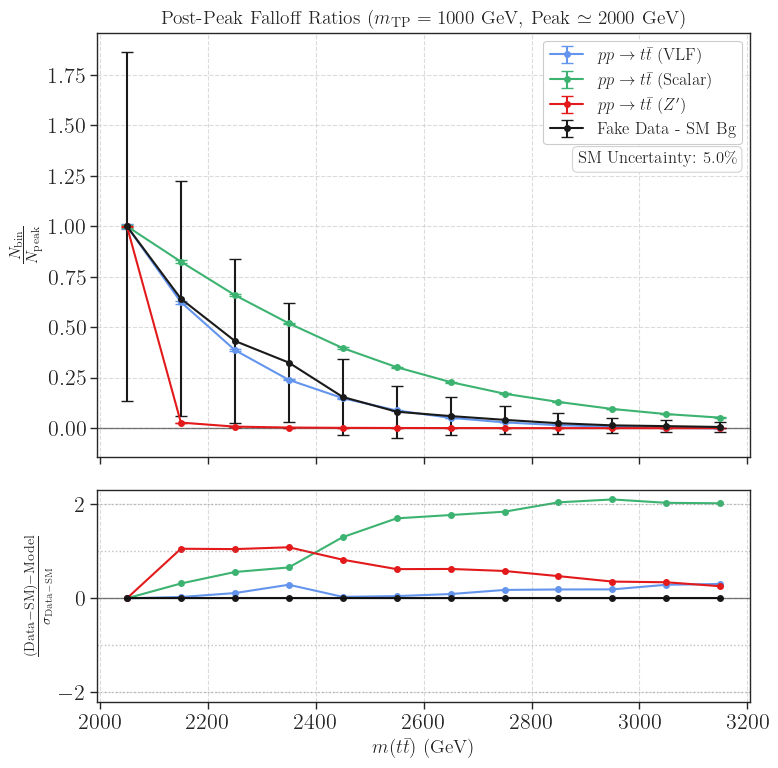

In [223]:
import numpy as np
import matplotlib.pyplot as plt

# ... (Assuming mTP, bins, bsm_hists, bsm_errs, sm_err, bsm_labels, bsm_colors are defined above) ...

# ==========================================
# ASSIGNING FAKE DATA
# ==========================================
# As specified, the fake data (Data - SM) is the last element in the bsm_hists array
fake_data_minus_sm = bsm_hists[-1]
fake_data_minus_sm_err = bsm_errs[-1]
# ==========================================

mTP = 1000.0 #GeV
n_bp = 12
peak = 2.0 * mTP
b_peak = 0
i = 0

while (peak >= bins[i] and i <= len(bins)):
    b_peak = i
    i += 1
print("Peak bin edge:", bins[b_peak])

ratios = []
ratios_err = []
model_sigmas = [] # List to store the significance for the subplot

# Computing the ratios and significance
for i, h in enumerate(bsm_hists):
    aux = []
    err = []
    sigmas = []
    for j in range(b_peak , b_peak + n_bp):
        A = h[j] # This is the Model (or Fake Data) yield in bin j
        B = h[b_peak]
        errA = bsm_errs[i][j]
        errB = bsm_errs[i][b_peak]
        
        # 1. Ratio Calculation (Top Plot)
        aux.append(A / B)
        
        # Safe propagation: avoids dividing by zero if the tail crosses zero
        safe_err = np.sqrt((errA / B)**2 + (A * errB / (B**2))**2)
        err.append(safe_err)
        
        # 2. Significance Calculation (Bottom Plot)
        # Formula: ((Fake Data - SM) - Model) / (Fake Data - SM Error)
        data_residual = fake_data_minus_sm[j]/fake_data_minus_sm[b_peak]
        data_residual_err = abs(data_residual) * np.sqrt((fake_data_minus_sm_err[j]/fake_data_minus_sm[j])**2 + 
                                                   (fake_data_minus_sm_err[b_peak]/fake_data_minus_sm[b_peak])**2)
        
        if data_residual_err > 0:
            sig = abs(data_residual - A/B) / data_residual_err
        else:
            sig = 0
            
        sigmas.append(sig)
        
    ratios.append(aux)
    ratios_err.append(err)
    model_sigmas.append(sigmas)

# ==========================================
# Plotting the ratios and significance subplot
# ==========================================

# Calculate the bin centers for the x-axis
x_centers = [(bins[j] + bins[j+1]) / 2.0 for j in range(b_peak , b_peak + n_bp)]

# Create figure with 2 subplots (Height ratio 2:1)
fig, (ax, ax_sig) = plt.subplots(2, 1, figsize=(8, 8), sharex=True, gridspec_kw={'height_ratios': [2, 1]})
plt.subplots_adjust(hspace=0.1) # Remove vertical gap between plots

# Loop over the calculated ratios to plot them
for k in range(len(ratios)):
    label = bsm_labels[k] if 'bsm_labels' in locals() else f"Model {k+1}"
    color = bsm_colors[k] if 'bsm_colors' in locals() else None
    
    # TOP PLOT: Ratios
    ax.errorbar(x_centers, ratios[k], yerr=ratios_err[k], fmt='o-', 
                capsize=4, label=label, color=color, markersize=4, linewidth=1.5)
    
    # BOTTOM PLOT: Significance (Sigmas)
    # For the fake data itself (the last element), this will plot at exactly 0. 
    # This is expected and serves as the visual baseline.
    ax_sig.plot(x_centers, model_sigmas[k], 'o-', color=color, markersize=4, linewidth=1.5)

# --- Top Plot (Ratio) Formatting ---
ax.text(0.98, 0.72, rf'SM Uncertainty: {sm_err*100:.1f}\%', 
        transform=ax.transAxes,      # Use axis coordinates instead of mass data coordinates
        fontsize=12, 
        verticalalignment='top',     # Anchor the text from its top edge
        horizontalalignment='right', # Anchor the text from its right edge
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='lightgray', alpha=1.0))

ax.set_ylabel(r'$\frac{N_{\mathrm{bin}}}{N_{\mathrm{peak}}}$', fontsize=16)
ax.set_title(r'Post-Peak Falloff Ratios ($m_{\mathrm{TP}} = 1000$ GeV, Peak $\simeq 2000$ GeV)', fontsize=14)
ax.axhline(0, color='black', linestyle='-', linewidth=1, alpha=0.5)
ax.grid(True, linestyle='--', alpha=0.7)
ax.legend(fontsize=12, framealpha=1.0)

# --- Bottom Plot (Significance) Formatting ---
ax_sig.set_xlabel(r'$m(t\bar{t})$ (GeV)', fontsize=14)
# Updated label to match the exact mathematical formula
ax_sig.set_ylabel(r'$\frac{(\mathrm{Data} - \mathrm{SM}) - \mathrm{Model}}{\sigma_{\mathrm{Data}-\mathrm{SM}}}$', fontsize=14)

# Reference lines for 0, 1 sigma, 2 sigma, etc. to easily visualize the deviations
ax_sig.axhline(0, color='black', linestyle='-', linewidth=1, alpha=0.5)
ax_sig.axhline(1, color='gray', linestyle=':', linewidth=1, alpha=0.5)
ax_sig.axhline(2, color='gray', linestyle=':', linewidth=1, alpha=0.5)
ax_sig.axhline(-1, color='gray', linestyle=':', linewidth=1, alpha=0.5)
ax_sig.axhline(-2, color='gray', linestyle=':', linewidth=1, alpha=0.5)

ax_sig.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('Post_Peak_Falloff_with_Sigmas.png', dpi=300)
plt.show()

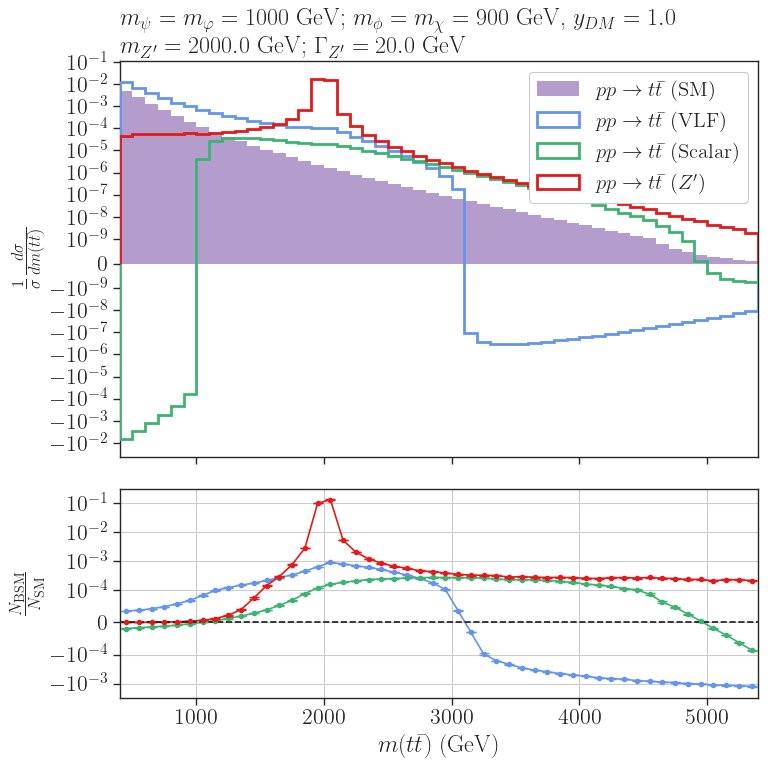

In [112]:
# Loop over the masses configurations. Each mass configuration has 4 items (2 models x 2 processes: qq, gg)
for i in range(0, len(data_NLO), 4):
    selected = data_NLO[i : i+4]

    # BSM masses and couplings
    mPsiT, mSDM = selected[0]['mass_params']
    yDM = selected[0]['ydm']
    
    # --- Setup and Binning ---
    fig, axarr = plt.subplots(2, sharex=True, gridspec_kw={'height_ratios': [1.9, 1]}, figsize=(8, 8))
    plt.subplots_adjust(left=0.12, bottom=0.12, right=0.97, top=None, wspace=None, hspace=0.1)

    if mPsiT < 600:
        bins = np.arange(400., 3000., 50.)
    elif mPsiT < 1000:
        bins = np.arange(500., 4000., 75.)
    else:
        bins = np.arange(400., 5500., 100.)
        
    x = (bins[:-1] + bins[1:]) / 2.0  
    bin_widths = np.diff(bins)

    ##############
    #  Main Plot #
    ##############
    
    pmodels = []
    labels_sm = []
    bsm_hists, bsm_errs, bsm_labels, bsm_colors = [], [], [], []

    # Plotting the SM 
    h_sm_total = np.zeros(len(bins)-1)
    hErr_sm_total_sq = np.zeros(len(bins)-1)
    
    for d in data_sm_exp:
        h, _ = np.histogram(d['mTT'], bins=bins, weights=d['weights'])
        hErr_sq, _ = np.histogram(d['mTT'], bins=bins, weights=np.array(d['weights'])**2)
        h_sm_total += h
        hErr_sm_total_sq += hErr_sq
    
    process = r'$p p \to t \bar{t}$'
    model = 'SM'
    pmodels.append(r'%s (%s)' % (process, model))
    label_sm = pmodels[-1]
    labels_sm.append(label_sm)
        
    integral_sm = np.sum(h_sm_total)
    h_sm = h_sm_total #/ (integral_sm * bin_widths) if integral_sm > 0 else h_sm_total
    hErr_sm = np.sqrt(hErr_sm_total_sq) #/ (integral_sm * bin_widths) if integral_sm > 0 else np.sqrt(hErr_sm_total_sq)
    
    # REMOVED np.abs() from weights
    axarr[0].hist(bins[:-1], weights=h_sm, label=label_sm, bins=bins, density = True,
                  color=sns.color_palette('Paired')[9], alpha=0.5, histtype='step', 
                  linewidth=0, fill=True, zorder=0)

    # Plotting the NLO BSM Data (Summing qq + gg for each model)
    for j in range(0, len(selected), 2):
        d = selected[j]
        d_next = selected[j+1]
        
        process = r'$p p \to t \bar{t}$'
        model = d['model']
        model_raw = d['model']
        model_name = str(np.atleast_1d(model_raw)[0])
        display_name = model_name.replace('1-loop ', '')
        pmodels.append(r'%s (%s)' % (process, display_name))
        label = pmodels[-1]
        
        color = get_color_by_mass(model, (mPsiT, mSDM))
        
        h1, _ = np.histogram(d['mTT'], bins=bins, weights=d['weights'])
        hErr1_sq, _ = np.histogram(d['mTT'], bins=bins, weights=np.array(d['weights'])**2)
        
        h2, _ = np.histogram(d_next['mTT'], bins=bins, weights=d_next['weights'])
        hErr2_sq, _ = np.histogram(d_next['mTT'], bins=bins, weights=np.array(d_next['weights'])**2)
        
        h_bsm_total = h1 + h2
        hErr_bsm_total_sq = hErr1_sq + hErr2_sq
        
        integral_bsm = np.sum(h_bsm_total)
        h_bsm = h_bsm_total #/ (integral_bsm * bin_widths) if integral_bsm > 0 else h_bsm_total
        hErr_bsm = np.sqrt(hErr_bsm_total_sq) #/ (integral_bsm * bin_widths) if integral_bsm > 0 else np.sqrt(hErr_bsm_total_sq)

        bsm_hists.append(h_bsm)
        bsm_errs.append(hErr_bsm)
        bsm_labels.append(label)
        bsm_colors.append(color)

        # REMOVED np.abs() from weights
        axarr[0].hist(bins[:-1], weights=h_bsm, label=label, bins=bins,
                      color=color, alpha=1.0, histtype='step',
                      linewidth=2, fill=False, zorder=3)

   
    h_z_total = np.zeros(len(bins)-1)
    hErr_z_total_sq = np.zeros(len(bins)-1)
    model_z = ""
    
    for d in data_Z:
        h, _ = np.histogram(d['mTT'], bins=bins, weights=d['weights'])
        hErr_sq, _ = np.histogram(d['mTT'], bins=bins, weights=np.array(d['weights'])**2)
        h_z_total += h
        hErr_z_total_sq += hErr_sq
        model_z = d['model']
        
    if len(data_Z) > 0:
        process = r'$p p \to t \bar{t}$'
        pmodels.append(r'%s (%s)' % (process, r'$Z^\prime$'))
        label_z = pmodels[-1]
        
        color_z = get_color_by_mass(model_z, (mPsiT, mSDM)) 
        
        integral_z = np.sum(h_z_total)
        h_z = h_z_total #/ (integral_z * bin_widths) if integral_z > 0 else h_z_total
        hErr_z = np.sqrt(hErr_z_total_sq) #/ (integral_z * bin_widths) if integral_z > 0 else np.sqrt(hErr_z_total_sq)
        
        bsm_hists.append(h_z)
        bsm_errs.append(hErr_z)
        bsm_labels.append(label_z)
        bsm_colors.append(color_z)
        
        # REMOVED np.abs() from weights
        axarr[0].hist(bins[:-1], weights=h_z, label=label_z, bins=bins,
                      color=color_z, alpha=1.0, histtype='step',
                      linewidth=2, fill=False, zorder=3)


    ############
    #  SUBPLOT #
    ############
    with np.errstate(divide='ignore', invalid='ignore'):
        # Calculate the raw ratio first to properly calculate the relative error
        raw_ratio = np.nan_to_num(np.array(bsm_hists) / h_sm)
        
        ratio = raw_ratio 
        
        # Propagate the errors for the ratio 
        err_bsm_rel = np.nan_to_num(np.array(bsm_errs) / np.array(bsm_hists))
        err_sm_rel = np.nan_to_num(hErr_sm / h_sm)
        
        ratio_err = np.abs(raw_ratio) * np.sqrt(err_bsm_rel**2 + err_sm_rel**2)


    for k, r in enumerate(ratio):
        # Using errorbar for the ratio points to show the propagated MC uncertainty
        axarr[1].errorbar(x, r, yerr=ratio_err[k], color=bsm_colors[k], fmt='o', ms=3, capsize=3.5, label=bsm_labels[k])
        axarr[1].plot(x, r, color=bsm_colors[k]) # Add a line connecting points


    #################
    #  Plot configs #
    #################
    
    # Safely extract Z' properties
    mZp = data_Z[0].get('mZp', 0.0) if len(data_Z) > 0 else 0.0
    wZp = data_Z[0].get('wZp', 0.0) if len(data_Z) > 0 else 0.0

    # Upper plot
    axarr[0].legend(framealpha=1.0, ncol=1, loc='upper right', fontsize=15)
    axarr[0].set_title(
        (r'$m_{\psi} = m_{\varphi} = %1.0f$ GeV; $m_{\phi} = m_\chi = %1.0f$ GeV, $y_{DM} = %1.1f$' + '\n' +
         r'$m_{Z^\prime} = %1.1f$ GeV; $\Gamma_{Z^\prime} = %1.1f$ GeV') % 
        (mPsiT, mSDM, yDM, mZp, 20.0), 
        loc='left'
    )
    
    # CHANGED: set_yscale to 'symlog' and adjusted linthresh
    axarr[0].set_yscale('symlog', linthresh=1e-9) 
    
    # CHANGED: Removed the absolute value bars | | from the label
    axarr[0].set_ylabel(r'$\frac{1}{\sigma}\frac{d \sigma}{d m(t\bar{t})}$')
    axarr[0].set_xlim(bins.min(), bins.max())


    # Bottom plot
    axarr[1].axhline(y=0, color='k', linestyle='--') # Baseline is now at 0
    axarr[1].set_ylabel(r'$\frac{N_{\mathrm{BSM}}}{ N_{\mathrm{SM}}}$') 
    axarr[1].set_xlabel(r'$m(t\bar{t})$ (GeV)')
    axarr[1].grid(True)
    axarr[1].set_yscale('symlog', linthresh = 0.0001)
    axarr[1].set_ylim([-0.003, 0.3])
    
    
    minor_tick_locations = np.concatenate((np.arange(-100.0, 0.0, 10.0 ), np.arange(-10.0, 1.0, 1.0 ), np.arange(0.0,11.0,1.0 ),
                                          np.arange(10.0, 100.0, 10.0), np.arange(100.0, 1100.0, 100.0),
                                          np.arange(1000.0, 4000.0, 1000.0))) # Add more as needed for your data range
    axarr[1].yaxis.set_minor_locator(FixedLocator(minor_tick_locations))

    plt.tight_layout()
    #filename = f"mtt_pp_mPsiT_{int(mPsiT)}_mSDM_{int(mSDM)}_ratio.png"
    plt.savefig('Dists_comparison_interference.png')
    plt.show()

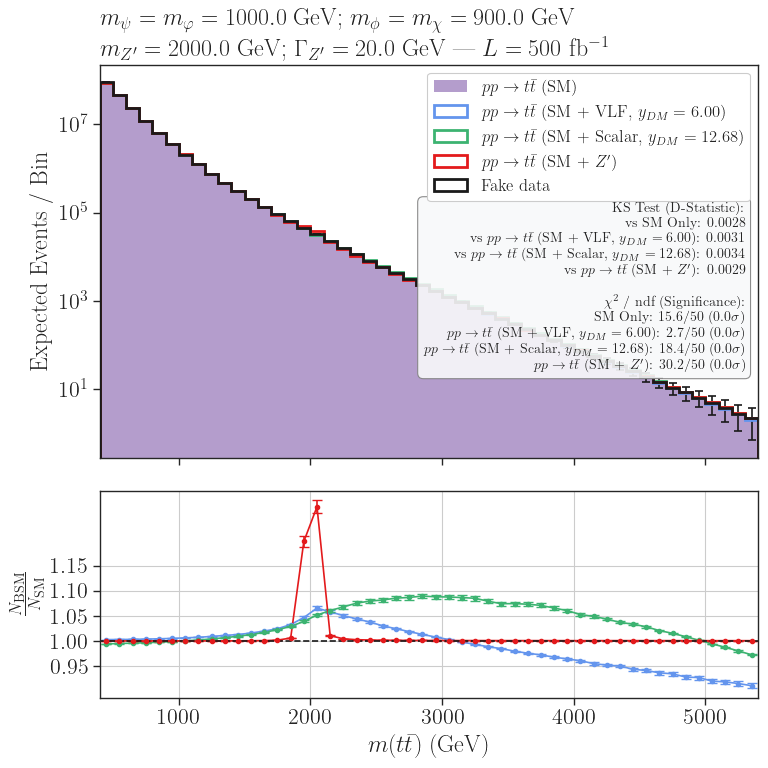

In [229]:


################
#  Physics Config
################
lum = 500 # fb^-1
lum_scale = lum * 1000.0 # Assuming weights are in pb, convert to fb

sm_err = 0.05 # 5% SM Systematic Uncertainty

# Loop over the masses configurations. Each mass configuration has 4 items (2 models x 2 processes: qq, gg)
for i in range(0, len(data_NLO), 4):
    selected = data_NLO[i : i+4]

    # BSM masses and couplings
    mPsiT, mSDM = selected[0]['mass_params']
    yDM = selected[0]['ydm']
    
    # --- Setup and Binning ---
    fig, axarr = plt.subplots(2, sharex=True, gridspec_kw={'height_ratios': [1.9, 1]}, figsize=(8, 8))
    plt.subplots_adjust(left=0.12, bottom=0.12, right=0.97, top=None, wspace=None, hspace=0.1)

    if mPsiT < 600:
        bins = np.arange(400., 3000., 50.)
    elif mPsiT < 1000:
        bins = np.arange(500., 4000., 75.)
    else:
        bins = np.arange(400., 5500., 100.)
        
    x = (bins[:-1] + bins[1:]) / 2.0  
    bin_widths = np.diff(bins)

    ##############
    #  Main Plot #
    ##############
    
    pmodels = []
    labels_sm = []
    
    bsm_hists, bsm_histsErr = [], []
    bsm_ratios, bsm_ratio_errs, bsm_labels, bsm_colors = [], [], [], []

    # ==========================================
    # 1 Plotting and Storing the Expected SM 
    # ==========================================
    h_sm_raw = np.zeros(len(bins)-1)
    hErr_sm_raw_sq = np.zeros(len(bins)-1)
    
    for n, d in enumerate(data_sm_exp):
        h, _ = np.histogram(d['mTT'], bins=bins, weights=d['weights'])
        hErr_sq, _ = np.histogram(d['mTT'], bins=bins, weights=np.array(d['weights'])**2)
        
        # APPLY LUMINOSITY SCALING
        h_sm_raw += h * lum_scale
        hErr_sm_raw_sq += hErr_sq * (lum_scale**2)
    
    process = r'$p p \to t \bar{t}$'
    model = 'SM'
    pmodels.append(r'%s (%s)' % (process, model))
    label_sm = pmodels[-1]
    labels_sm.append(label_sm)
        
    # Extract final Expected SM Events
    h_sm = h_sm_raw / (n + 1)
    hErr_sm_stat_sq = hErr_sm_raw_sq / ((n + 1)**2)
    
    # APPLY SM SYSTEMATIC ERROR
    hErr_sm = np.sqrt(hErr_sm_stat_sq + (sm_err * h_sm)**2)
    
    axarr[0].hist(bins[:-1], weights=np.abs(h_sm), label=label_sm, bins=bins, density=False,
                  color=sns.color_palette('Paired')[9], alpha=0.5, histtype='step', 
                  linewidth=0, fill=True, zorder=0)

    # ==========================================
    #  Plotting the NLO BSM Data (SM + BSM)
    # ==========================================
    y_DM = {'1-loop VLF': 6.0, '1-loop Scalar': 1.268000e+01}
    #y_DM = {'1-loop VLF': 1.0, '1-loop Scalar': 1.000e+00}
    for j in range(0, len(selected), 2):
        d = selected[j]
        d_next = selected[j+1]
        
        process = r'$p p \to t \bar{t}$'
        
        model_raw = d['model']
        model_name = str(np.atleast_1d(model_raw)[0])
        val_y_dm = y_DM.get(model_name, 1.0)
        
        display_name = model_name.replace('1-loop ', '')
        pmodels.append(r'%s (SM + %s, $y_{DM} = %.2f$)' % (process, display_name, val_y_dm))
        label = pmodels[-1]
        
        color = get_color_by_mass(model_name, (mPsiT, mSDM))
        
        h1, _ = np.histogram(d['mTT'], bins=bins, weights=d['weights'])
        hErr1_sq, _ = np.histogram(d['mTT'], bins=bins, weights=np.array(d['weights'])**2)
        
        h2, _ = np.histogram(d_next['mTT'], bins=bins, weights=d_next['weights'])
        hErr2_sq, _ = np.histogram(d_next['mTT'], bins=bins, weights=np.array(d_next['weights'])**2)
        
        scale_weight = y_DM.get(model_name, 1.0)**2 
        
        # APPLY LUMINOSITY SCALING TO SIGNAL
        h_bsm_raw = (h1 + h2) * scale_weight * lum_scale
        hErr_bsm_raw_sq = (hErr1_sq + hErr2_sq) * (scale_weight**2) * (lum_scale**2)
        
        # Combine SM and Signal
        h_combined = h_bsm_raw + h_sm
        hErr_combined = np.sqrt(hErr_bsm_raw_sq + hErr_sm**2) # Error includes SM systematics
        
        bsm_hists.append(h_combined)
        bsm_histsErr.append(hErr_combined)
        
        axarr[0].hist(bins[:-1], weights=np.abs(h_combined), label=label, bins=bins,
                      color=color, alpha=1.0, histtype='step', density=False,
                      linewidth=2, fill=False, zorder=3)

        # --- Propagating error for Ratio ---
        with np.errstate(divide='ignore', invalid='ignore'):
            ratio = h_combined / h_sm
            err_bsm_stat = np.sqrt(hErr_bsm_raw_sq)
            
            ratio_err = (1.0 / h_sm) * np.sqrt(err_bsm_stat**2 + (h_bsm_raw / h_sm)**2 * hErr_sm**2)
            
            zero_mask = (h_sm == 0)
            ratio[zero_mask] = np.nan
            ratio_err[zero_mask] = np.nan
            
        bsm_ratios.append(ratio)
        bsm_ratio_errs.append(ratio_err)
        bsm_labels.append(label)
        bsm_colors.append(color)

    # ==========================================
    # Plotting the Z' Data (SM + Z')
    # ==========================================
    h_z_raw = np.zeros(len(bins)-1)
    hErr_z_raw_sq = np.zeros(len(bins)-1)
    model_z = ""
    
    for d in data_Z:
        h, _ = np.histogram(d['mTT'], bins=bins, weights=d['weights'])
        hErr_sq, _ = np.histogram(d['mTT'], bins=bins, weights=np.array(d['weights'])**2)
        
        # APPLY LUMINOSITY SCALING
        h_z_raw += h * lum_scale
        hErr_z_raw_sq += hErr_sq * (lum_scale**2)
        
        m_arr = d['model']
        model_z = str(np.atleast_1d(m_arr)[0])
        
    if len(data_Z) > 0:
        process = r'$p p \to t \bar{t}$'
        pmodels.append(r'%s (SM + %s)' % (process, r'$Z^\prime$'))
        label_z = pmodels[-1]
        
        color_z = get_color_by_mass(model_z, (mPsiT, mSDM)) 
        
        h_combined_z = h_z_raw + h_sm
        hErr_combined_z = np.sqrt(hErr_z_raw_sq + hErr_sm**2) 
        
        bsm_hists.append(h_combined_z)
        bsm_histsErr.append(hErr_combined_z)
        
        axarr[0].hist(bins[:-1], weights=np.abs(h_combined_z), label=label_z, bins=bins,
                      color=color_z, alpha=1.0, histtype='step', density=False,
                      linewidth=2, fill=False, zorder=3)
                      
        # --- Propagating Error for Z' Ratio ---
        with np.errstate(divide='ignore', invalid='ignore'):
            ratio = h_combined_z / h_sm
            err_z_stat = np.sqrt(hErr_z_raw_sq)
            
            ratio_err = (1.0 / h_sm) * np.sqrt(err_z_stat**2 + (h_z_raw / h_sm)**2 * hErr_sm**2)
            
            zero_mask = (h_sm == 0)
            ratio[zero_mask] = np.nan
            ratio_err[zero_mask] = np.nan
            
        bsm_ratios.append(ratio)
        bsm_ratio_errs.append(ratio_err)
        bsm_labels.append(label_z)
        bsm_colors.append(color_z)
        
    ##################################
    # Adding fake data to the hists  #
    ##################################
    h_fake = np.zeros(len(bins)-1)
    
    for n, d in enumerate(fake_data):
        h, _ = np.histogram(d['mTT'], bins=bins, weights=d['weights'])
        h_fake += h * lum_scale # APPLY LUMINOSITY SCALING
        
    # The total expected observation of the fake data
    N_obs = h_fake / (n + 1)
    
    # Statistical uncertainty of observed data is just sqrt(N)
    stat_variance_obs = np.abs(N_obs) 
    
    bsm_hists.append(N_obs)
    bsm_histsErr.append(np.sqrt(stat_variance_obs)) 
    
    bsm_labels.append('Fake Data ')
    bsm_colors.append('k')
    
    axarr[0].hist(
        bins[:-1], weights=np.abs(bsm_hists[-1]), label='Fake data ', bins=bins,
        color='k', alpha=1.0, histtype='step', 
        linewidth=2, fill=False, zorder=3, density=False
    )
    
    axarr[0].errorbar(
        x, np.abs(bsm_hists[-1]), yerr=bsm_histsErr[-1], color='k', 
        fmt='none', capsize=3, capthick=1.2, barsabove=True
    )        
    
    ######################################################
    #  Statistical Tests (KS and Chi-Squared)            #
    ######################################################
    
    fake_obs = bsm_hists[-1] 
    fake_obs_variance = bsm_histsErr[-1]**2
    
    # Dynamically build hypotheses list containing: (Name, Hist, Error)
    hypotheses = [("SM Only", h_sm, hErr_sm)]
    for k in range(len(bsm_hists) - 1):
        hypotheses.append((bsm_labels[k], bsm_hists[k], bsm_histsErr[k]))
    
    # Ensure we only use valid bins
    valid_mask = (h_sm > 0)
    ndf = np.sum(valid_mask)
    
    stats_lines = ["KS Test (D-Statistic):"]
    
    # 1. KS Test Calculation
    fake_yield = fake_obs[valid_mask]
    cdf_fake = np.cumsum(fake_yield)
    cdf_fake_norm = cdf_fake / cdf_fake[-1] if cdf_fake[-1] != 0 else cdf_fake
    
    for name, hyp_hist, _ in hypotheses:
        hyp_yield = hyp_hist[valid_mask]
        cdf_hyp = np.cumsum(hyp_yield)
        cdf_hyp_norm = cdf_hyp / cdf_hyp[-1] if cdf_hyp[-1] != 0 else cdf_hyp
        
        D_statistic = np.max(np.abs(cdf_hyp_norm - cdf_fake_norm))
        stats_lines.append(f"vs {name}: {D_statistic:.4f}")
        
    stats_lines.append("")
    stats_lines.append(r"$\chi^2$ / ndf (Significance):")
    
    # 2. Chi-Squared Calculation
    for name, hyp_hist, hyp_err in hypotheses:
        O = fake_obs[valid_mask]
        E = hyp_hist[valid_mask]
        
        # Total Variance = Var(FakeData) + Var(Hypothesis)
        total_variance = fake_obs_variance[valid_mask] + hyp_err[valid_mask]**2
        
        # Calculate Chi2 (only where variance > 0 to be safe)
        safe_variance_mask = total_variance > 0
        chi2_val = np.sum((O[safe_variance_mask] - E[safe_variance_mask])**2 / total_variance[safe_variance_mask])
        
        # Calculate Significance
        p_value = stats.chi2.sf(chi2_val, ndf)
        if p_value >= 0.5:
            z_score = 0.0
        else:
            z_score = stats.norm.isf(max(p_value, 1e-15))
            
        stats_lines.append(f"{name}: {chi2_val:.1f}/{ndf} ({z_score:.1f}" + r"$\sigma$)")

    # Combine into one text string
    stats_text = "\n".join(stats_lines)

    # Place the stats text box on the plot
    axarr[0].text(0.98, 0.65, stats_text, 
                  transform=axarr[0].transAxes,      
                  fontsize=10, 
                  verticalalignment='top',     
                  horizontalalignment='right', 
                  bbox=dict(boxstyle='round,pad=0.4', facecolor='#f8f9fa', edgecolor='gray', alpha=0.9))
    
    ############
    #  SUBPLOT #
    ############
    
    for k, r in enumerate(bsm_ratios):
        axarr[1].errorbar(x, r, yerr=bsm_ratio_errs[k], color=bsm_colors[k], fmt='o', ms=3, capsize=3.5, label=bsm_labels[k])
        axarr[1].plot(x, r, color=bsm_colors[k]) 

    #################
    #  Plot configs #
    #################
    
    mZp = data_Z[0].get('mZp', 0.0) if len(data_Z) > 0 else 0.0
    wZp = data_Z[0].get('wZp', 0.0) if len(data_Z) > 0 else 0.0

    axarr[0].legend(framealpha=1.0, ncol=1, loc='upper right', fontsize=12)
    axarr[0].set_title(
        (r'$m_{\psi} = m_{\varphi} = %1.1f$ GeV; $m_{\phi} = m_\chi = %1.1f$ GeV' + '\n' +
         r'$m_{Z^\prime} = %1.1f$ GeV; $\Gamma_{Z^\prime} = %1.1f$ GeV | $L = %d$ fb$^{-1}$') % 
        (mPsiT, mSDM, mZp, 20.0, lum), 
        loc='left'
    )
    axarr[0].set_yscale('log')
    axarr[0].set_ylabel(r'Expected Events / Bin')
    axarr[0].set_xlim(bins.min(), bins.max())

    axarr[1].axhline(y=1.0, color='k', linestyle='--') 
    axarr[1].set_ylabel(r'$\frac{N_{\mathrm{BSM}}}{ N_{\mathrm{SM}}}$') 
    axarr[1].set_xlabel(r'$m(t\bar{t})$ (GeV)')
    axarr[1].grid(True)
    axarr[1].set_yticks(np.arange(0.95,1.2, 0.05))
    
    plt.tight_layout()
    #plt.savefig('Dists_comparison.png')
    plt.show()

In [230]:
mTT_start = 1.5 * mPsiT
tail_mask = bins[:-1] >= mTT_start


tail_sum_NLO = np.sum(bsm_hists[0][tail_mask]) 
tail_sum_S   = np.sum( bsm_hists[1][tail_mask] )
tail_sum_Zp  = np.sum( bsm_hists[2][tail_mask]) 

yDM_S = np.sqrt(7.0**2 * tail_sum_NLO/tail_sum_S)
mu_Zp = np.sqrt(7.0**2 *tail_sum_NLO/tail_sum_Zp)
# Print the results
print(f"--- Sum for mTT >= {mTT_start} GeV ---")
print(f"VLF NLO:      {tail_sum_NLO:.5e}")
print(f"Scalar NLO:   {tail_sum_S:.5e}")
print(f"Z prime:      {tail_sum_Zp:.5e}")
print(f"yDM_S:      {yDM_S:.5e}")
print(f"mu_Z:      {mu_Zp:.5e}")
print()

mTT_start = 1.5 * mPsiT
tail_mask = bins[:-1] >= mTT_start


tail_sum_NLO = np.sum(bsm_hists[0][tail_mask]) - np.sum(h_sm[tail_mask]) 
tail_sum_S   = np.sum( bsm_hists[1][tail_mask] )- np.sum(h_sm[tail_mask]) 
tail_sum_Zp  = np.sum( bsm_hists[2][tail_mask]) - np.sum(h_sm[tail_mask]) 

yDM_S = np.sqrt( tail_sum_NLO/tail_sum_S)
mu_Zp = np.sqrt(tail_sum_NLO/tail_sum_Zp)
# Print the results
print(f"--- Sum for mTT >= {mTT_start} GeV ---")
print(f"VLF NLO:      {tail_sum_NLO:.5e}")
print(f"Scalar NLO:   {tail_sum_S:.5e}")
print(f"Z prime:      {tail_sum_Zp:.5e}")
print(f"yDM_S:      {yDM_S:.5e}")
print(f"mu_Z:      {mu_Zp:.5e}")
print()

--- Sum for mTT >= 1500.0 GeV ---
VLF NLO:      6.50429e+05
Scalar NLO:   6.50780e+05
Z prime:      6.50797e+05
yDM_S:      6.99811e+00
mu_Z:      6.99802e+00

--- Sum for mTT >= 1500.0 GeV ---
VLF NLO:      1.68602e+04
Scalar NLO:   1.72116e+04
Z prime:      1.72281e+04
yDM_S:      9.89739e-01
mu_Z:      9.89265e-01



Peak bin starts at: 2000.0


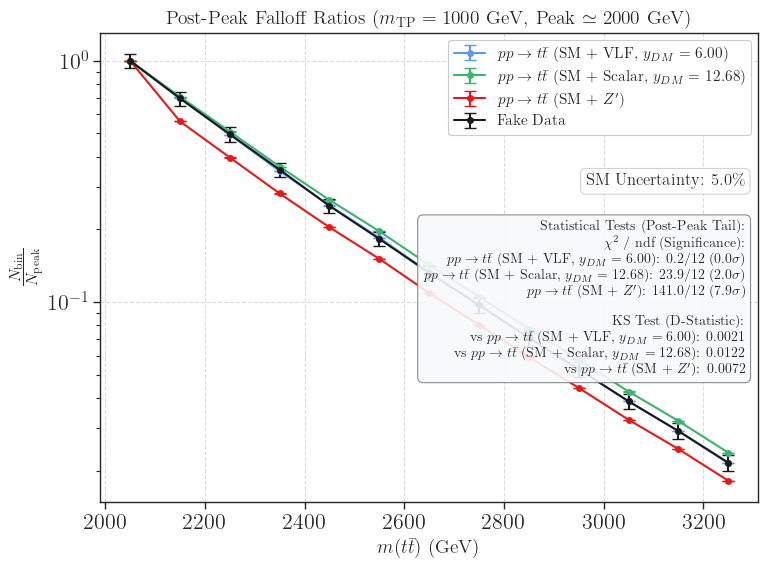

In [231]:

mTP = 1000.0 #GeV
n_bp = 13
peak = 2.0 * mTP
b_peak = 0
i = 0

while (peak >= bins[i] and i<=len(bins)):
    b_peak = i
    i+=1
print(f"Peak bin starts at: {bins[b_peak]}")

ratios = []
ratios_err = []

# Computing the ratios
for i, h in enumerate(bsm_hists):
    aux = []
    err = []
    # Loop starts at b_peak, but we will ignore the 0th element in the stats test!
    for j in range(b_peak, b_peak + n_bp):
        A = h[j]
        B = h[b_peak]
        errA = bsm_errs[i][j]
        errB = bsm_errs[i][b_peak]
        
        aux.append(A / B)
        
        # Safe propagation: avoids dividing by zero if the tail crosses zero
        safe_err = np.sqrt((errA / B)**2 + (A * errB / (B**2))**2)
        err.append(safe_err)
        
    ratios.append(aux)
    ratios_err.append(err)

# ==========================================
# Statistical Tests (Fake Data vs Theory)
# ==========================================
# Assuming Fake Data is the LAST element in your lists
fake_ratio = np.array(ratios[-1])
fake_ratio_err = np.array(ratios_err[-1])

# We slice [1:] to skip the b_peak itself 
valid_fake_ratio = fake_ratio[1:]
valid_fake_err = fake_ratio_err[1:]

stats_lines = [
    "Statistical Tests (Post-Peak Tail):",
    r"$\chi^2$ / ndf (Significance):"
]

for k in range(len(ratios) - 1): # Skip the last element (which is Fake Data itself)
    hyp_ratio = np.array(ratios[k])[1:]
    hyp_err = np.array(ratios_err[k])[1:]
    name = bsm_labels[k]
    
    # -----------------------------------------------------------------
    # MATH FIX: To treat the bins as independent for a standard Chi2, 
    # we isolate the variance of just the NUMERATOR (the tail bins) 
    # and ignore the shared denominator error that bloats the variance.
    # -----------------------------------------------------------------
    # Extract the raw numerator errors from the original arrays
    raw_err_fake = np.array(bsm_errs[-1])[b_peak+1 : b_peak+n_bp] / bsm_hists[-1][b_peak]
    raw_err_hyp  = np.array(bsm_errs[k])[b_peak+1 : b_peak+n_bp] / bsm_hists[k][b_peak]
    
    total_variance = raw_err_fake**2 + raw_err_hyp**2
    
    # Calculate Chi2
    valid_mask = total_variance > 0
    ndf = np.sum(valid_mask)
    
    if ndf > 0:
        chi2_val = np.sum((valid_fake_ratio[valid_mask] - hyp_ratio[valid_mask])**2 / total_variance[valid_mask])
        p_value = stats.chi2.sf(chi2_val, ndf)
        
        # PYTHON FIX: Cap the p-value at 0.5 to prevent stats.norm.isf from outputting -inf
        if p_value >= 0.5:
            z_score = 0.0
        else:
            z_score = stats.norm.isf(max(p_value, 1e-15))
    else:
        chi2_val, z_score = 0.0, 0.0
    
    stats_lines.append(f"{name}: {chi2_val:.1f}/{ndf} ({z_score:.1f}" + r"$\sigma$)")

# 2. Kolmogorov-Smirnov (KS) Test 
# (Warning: A CDF of a ratio is not a true statistical probability distribution)
stats_lines.append("")
stats_lines.append("KS Test (D-Statistic):")

cdf_fake = np.cumsum(valid_fake_ratio)
cdf_fake_norm = cdf_fake / cdf_fake[-1] if cdf_fake[-1] != 0 else cdf_fake

for k in range(len(ratios) - 1):
    hyp_ratio = np.array(ratios[k])[1:]
    name = bsm_labels[k]
    
    cdf_hyp = np.cumsum(hyp_ratio)
    cdf_hyp_norm = cdf_hyp / cdf_hyp[-1] if cdf_hyp[-1] != 0 else cdf_hyp
    
    D_stat = np.max(np.abs(cdf_fake_norm - cdf_hyp_norm))
    stats_lines.append(f"vs {name}: {D_stat:.4f}")

# Join the list into a single safe string
stats_text = "\n".join(stats_lines)


# ==========================================
# Plotting the ratios for each model
# ==========================================

# Calculate the bin centers for the x-axis
x_centers = [(bins[j] + bins[j+1]) / 2.0 for j in range(b_peak, b_peak + n_bp)]

fig, ax = plt.subplots(figsize=(8, 6))

# Loop over the calculated ratios to plot them
for k in range(len(ratios)):
    label = bsm_labels[k] if 'bsm_labels' in locals() else f"Model {k+1}"
    color = bsm_colors[k] if 'bsm_colors' in locals() else None
    
    ax.errorbar(x_centers, ratios[k], yerr=ratios_err[k], fmt='o-', 
                capsize=4, label=label, color=color, markersize=4, linewidth=1.5)


# Formatting the plot to match the style of your previous physics plots
ax.set_xlabel(r'$m(t\bar{t})$ (GeV)', fontsize=14)
ax.set_ylabel(r'$\frac{N_{\mathrm{bin}}}{N_{\mathrm{peak}}}$', fontsize=16)
ax.set_title(r'Post-Peak Falloff Ratios ($m_{\mathrm{TP}} = 1000$ GeV, Peak $\simeq 2000$ GeV)', fontsize=14)

# Adding a horizontal line at 0 so you can clearly see the negative interference crossing!
ax.axhline(0, color='black', linestyle='-', linewidth=1, alpha=0.5)

ax.grid(True, linestyle='--', alpha=0.7)

# --- ANNOTATIONS ---
# --- ANNOTATIONS ---
# Place the Legend
ax.legend(fontsize=11, framealpha=1.0, loc='upper right')
ax.set_yscale('log')

# Place the SM Uncertainty Box safely using .format()
sm_text = r"SM Uncertainty: {:.1f}\%".format(sm_err * 100)
ax.text(0.98, 0.70, sm_text, 
        transform=ax.transAxes,      
        fontsize=12, 
        verticalalignment='top',     
        horizontalalignment='right', 
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='lightgray', alpha=1.0))

# Place the Statistics Box below the SM Uncertainty Box
ax.text(0.98, 0.60, stats_text, 
        transform=ax.transAxes,      
        fontsize=10, 
        verticalalignment='top',         # Anchor to the top edge 
        horizontalalignment='right',     # Anchor to the right edge (aligns with the boxes above it)
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#f8f9fa', edgecolor='gray', alpha=0.9))

plt.tight_layout()
plt.savefig('Post_Peak_Falloff.png', dpi=300)
plt.show()

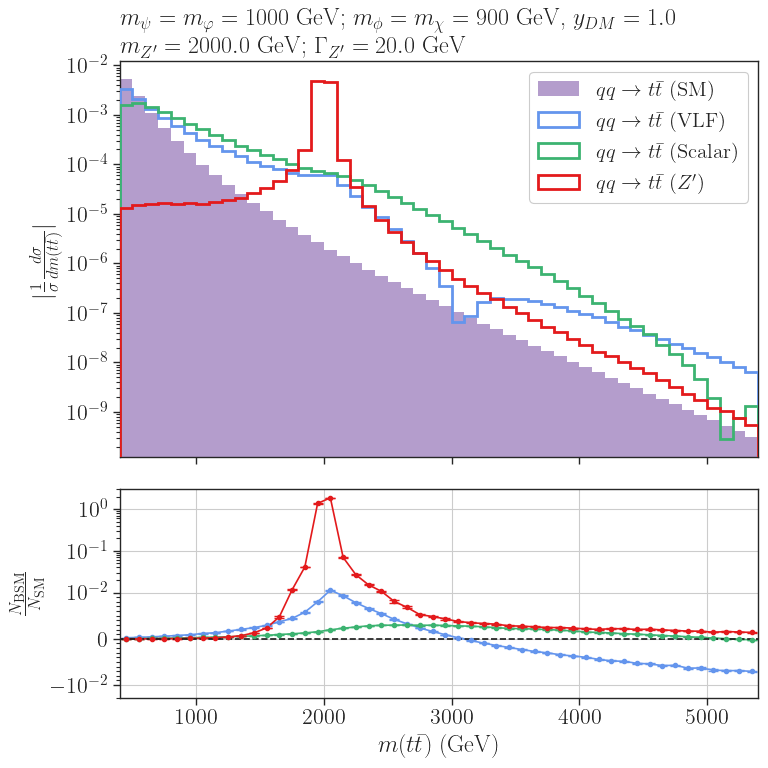

In [70]:


# Loop over the masses configurations. Each mass configuration has 4 items (2 models x 2 processes: qq, gg)
for i in range(0, len(data_NLO), 4):
    selected = data_NLO[i : i+4]

    # BSM masses and couplings
    mPsiT, mSDM = selected[0]['mass_params']
    yDM = selected[0]['ydm']
    
    # --- Setup and Binning ---
    fig, axarr = plt.subplots(2, sharex=True, gridspec_kw={'height_ratios': [1.9, 1]}, figsize=(8, 8))
    plt.subplots_adjust(left=0.12, bottom=0.12, right=0.97, top=None, wspace=None, hspace=0.1)

    if mPsiT < 600:
        bins = np.arange(400., 3000., 50.)
    elif mPsiT < 1000:
        bins = np.arange(500., 4000., 75.)
    else:
        bins = np.arange(400., 5500., 100.)
        
    x = (bins[:-1] + bins[1:]) / 2.0  
    bin_widths = np.diff(bins)

    ##############
    #  Main Plot #
    ##############
    
    pmodels = []
    labels_sm = []
    bsm_hists, bsm_errs, bsm_labels, bsm_colors = [], [], [], []

    # ==========================================
    #  Plotting the SM (ONLY qq)
    # ==========================================
    h_sm_total = np.zeros(len(bins)-1)
    hErr_sm_total_sq = np.zeros(len(bins)-1)
    
    for d in data_qq_sm_exp:
        # Safely extract process string
        proc_str = str(np.atleast_1d(d['process'])[0]).lower()
        
        # SKIP gg contributions
        if 'q' not in proc_str:
            continue
            
        h, _ = np.histogram(d['mTT'], bins=bins, weights=d['weights'])
        hErr_sq, _ = np.histogram(d['mTT'], bins=bins, weights=np.array(d['weights'])**2)
        h_sm_total += h
        hErr_sm_total_sq += hErr_sq
    
    process = r'$q q \to t \bar{t}$'  # Updated Label
    model = 'SM'
    pmodels.append(r'%s (%s)' % (process, model))
    label_sm = pmodels[-1]
    labels_sm.append(label_sm)
        
    integral_sm = np.sum(h_sm_total)
    h_sm = h_sm_total #/ (integral_sm * bin_widths) if integral_sm > 0 else h_sm_total
    hErr_sm = np.sqrt(hErr_sm_total_sq) #/ (integral_sm * bin_widths) if integral_sm > 0 else np.sqrt(hErr_sm_total_sq)
    
    axarr[0].hist(bins[:-1], weights=np.abs(h_sm), label=label_sm, bins=bins, density=True,
                  color=sns.color_palette('Paired')[9], alpha=0.5, histtype='step', 
                  linewidth=0, fill=True, zorder=0)

    # ==========================================
    #  Plotting the NLO BSM Data (ONLY qq)
    # ==========================================
    for d in selected:
        # Safely extract process string
        proc_str = str(np.atleast_1d(d['process'])[0]).lower()
        
        # SKIP gg contributions
        if 'q' not in proc_str:
            continue
            
        process = r'$q q \to t \bar{t}$'  # Updated Label
        model_raw = d['model']
        model_name = str(np.atleast_1d(model_raw)[0])
        display_name = model_name.replace('1-loop ', '')
        
        pmodels.append(r'%s (%s)' % (process, display_name))
        label = pmodels[-1]
        
        color = get_color_by_mass(model_name, (mPsiT, mSDM))
        
        # Calculate for qq only
        h_bsm_total, _ = np.histogram(d['mTT'], bins=bins, weights=d['weights'])
        hErr_bsm_total_sq, _ = np.histogram(d['mTT'], bins=bins, weights=np.array(d['weights'])**2)
        
        integral_bsm = np.sum(h_bsm_total)
        h_bsm = h_bsm_total #/ (integral_bsm * bin_widths) if integral_bsm > 0 else h_bsm_total
        hErr_bsm = np.sqrt(hErr_bsm_total_sq) #/ (integral_bsm * bin_widths) if integral_bsm > 0 else np.sqrt(hErr_bsm_total_sq)

        bsm_hists.append(h_bsm)
        bsm_errs.append(hErr_bsm)
        bsm_labels.append(label)
        bsm_colors.append(color)

        axarr[0].hist(bins[:-1], weights=np.abs(h_bsm), label=label, bins=bins,
                      color=color, alpha=1.0, histtype='step', density=True,
                      linewidth=2, fill=False, zorder=3)

    # ==========================================
    #  Plotting the Z' Data (ONLY qq)
    # ==========================================
    h_z_total = np.zeros(len(bins)-1)
    hErr_z_total_sq = np.zeros(len(bins)-1)
    model_z = ""
    
    for d in data_Z:
        # Safely extract process string
        proc_str = str(np.atleast_1d(d['process'])[0]).lower()
        
        
            
        h, _ = np.histogram(d['mTT'], bins=bins, weights=d['weights'])
        hErr_sq, _ = np.histogram(d['mTT'], bins=bins, weights=np.array(d['weights'])**2)
        h_z_total += h
        hErr_z_total_sq += hErr_sq
        model_z = str(np.atleast_1d(d['model'])[0])
        
    if len(data_Z) > 0 and integral_sm > 0: # Ensure we actually gathered qq data
        process = r'$q q \to t \bar{t}$' # Updated Label
        pmodels.append(r'%s (%s)' % (process, r'$Z^\prime$'))
        label_z = pmodels[-1]
        
        color_z = get_color_by_mass(model_z, (mPsiT, mSDM)) 
        
        integral_z = np.sum(h_z_total)
        h_z = h_z_total #/ (integral_z * bin_widths) if integral_z > 0 else h_z_total
        hErr_z = np.sqrt(hErr_z_total_sq) #/ (integral_z * bin_widths) if integral_z > 0 else np.sqrt(hErr_z_total_sq)
        
        bsm_hists.append(h_z)
        bsm_errs.append(hErr_z)
        bsm_labels.append(label_z)
        bsm_colors.append(color_z)
        
        axarr[0].hist(bins[:-1], weights=np.abs(h_z), label=label_z, bins=bins,
                      color=color_z, alpha=1.0, histtype='step', density=True,
                      linewidth=2, fill=False, zorder=3)


    ############
    #  SUBPLOT #
    ############
    with np.errstate(divide='ignore', invalid='ignore'):
        # Calculate the raw ratio first to properly calculate the relative error
        raw_ratio = np.nan_to_num(np.array(bsm_hists) / h_sm)
        
        ratio = raw_ratio 
        
        # Propagate the errors for the ratio 
        err_bsm_rel = np.nan_to_num(np.array(bsm_errs) / np.array(bsm_hists))
        err_sm_rel = np.nan_to_num(hErr_sm / h_sm)
        
        ratio_err = np.abs(raw_ratio) * np.sqrt(err_bsm_rel**2 + err_sm_rel**2)


    for k, r in enumerate(ratio):
        # Using errorbar for the ratio points to show the propagated MC uncertainty
        axarr[1].errorbar(x, r, yerr=ratio_err[k], color=bsm_colors[k], fmt='o', ms=3, capsize=3.5, label=bsm_labels[k])
        axarr[1].plot(x, r, color=bsm_colors[k]) # Add a line connecting points


    #################
    #  Plot configs #
    #################
    
    # Safely extract Z' properties
    mZp = data_Z[0].get('mZp', 0.0) if len(data_Z) > 0 else 0.0
    wZp = data_Z[0].get('wZp', 0.0) if len(data_Z) > 0 else 0.0

    # Upper plot
    axarr[0].legend(framealpha=1.0, ncol=1, loc='upper right', fontsize=15)
    axarr[0].set_title(
        (r'$m_{\psi} = m_{\varphi} = %1.0f$ GeV; $m_{\phi} = m_\chi = %1.0f$ GeV, $y_{DM} = %1.1f$' + '\n' +
         r'$m_{Z^\prime} = %1.1f$ GeV; $\Gamma_{Z^\prime} = %1.1f$ GeV') % 
        (mPsiT, mSDM, yDM, mZp, 20.0), 
        loc='left'
    )
    axarr[0].set_yscale('log')
    axarr[0].set_ylabel(r'$|\frac{1}{\sigma}\frac{d \sigma}{d m(t\bar{t})}|$')
    axarr[0].set_xlim(bins.min(), bins.max())


    # Bottom plot
    axarr[1].axhline(y=0, color='k', linestyle='--') # Baseline is now at 0
    axarr[1].set_ylabel(r'$\frac{N_{\mathrm{BSM}}}{ N_{\mathrm{SM}}}$') 
    axarr[1].set_xlabel(r'$m(t\bar{t})$ (GeV)')
    axarr[1].grid(True)
    axarr[1].set_yscale('symlog', linthresh=0.01)
    
    axarr[1].set_ylim([-0.02, 3.0]) 
    
    axarr[1].set_yticks([-0.01, 0.0, 0.01, 0.1, 1.0])
    
    minor_tick_locations = np.concatenate((
        np.arange(-0.1, -0.01, 0.01),   
        np.arange(-0.01, 0.01, 0.001),  
        np.arange(0.01, 0.1, 0.01),    
        np.arange(0.1, 1.0, 0.1),       
        np.arange(1.0, 10.0, 1.0)       
    )) 
    
    # (Ensure 'from matplotlib.ticker import FixedLocator' is at the top of your script)
    axarr[1].yaxis.set_minor_locator(FixedLocator(minor_tick_locations))

    plt.tight_layout()
    plt.savefig('Dists_qq_comparison_interference.png')
    plt.show()